# Project 3 — Non-Linear Shape Clustering Showdown: DBSCAN vs K-Means vs Hierarchical

**Purpose:** This project is a direct, visual head-to-head comparison of all three clustering
algorithms you've now learned (K-Means, Hierarchical, DBSCAN) across several dataset shapes --
some easy, some deliberately hard -- to build strong intuition for **when each algorithm shines
and when it fails**. This is exactly the kind of comparison a data scientist runs before
committing to an algorithm on a new, unfamiliar dataset.


## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN, KMeans, AgglomerativeClustering
from sklearn.datasets import make_moons, make_blobs, make_circles
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)
plt.rcParams['figure.figsize'] = (8, 5)


## 2. Build 4 Test Datasets of Increasing Difficulty

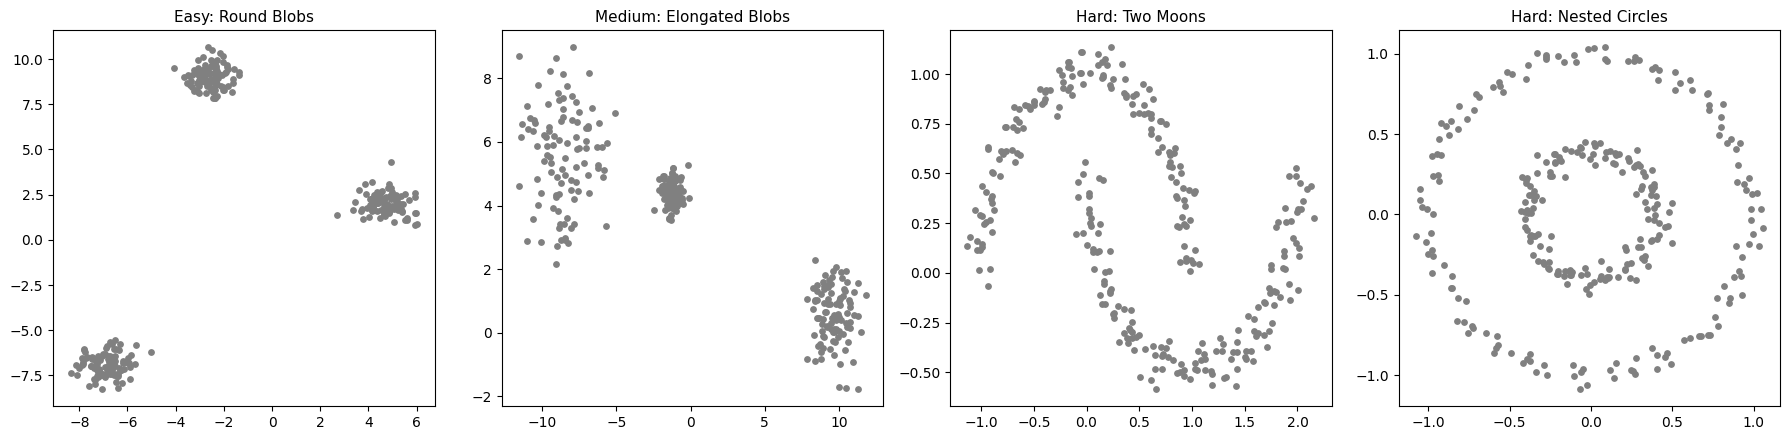

In [2]:
n_samples = 300

datasets = {
    'Easy: Round Blobs': make_blobs(n_samples=n_samples, centers=3, cluster_std=0.6, random_state=42)[0],
    'Medium: Elongated Blobs': make_blobs(n_samples=n_samples, centers=3, cluster_std=[1.5, 0.4, 0.9], random_state=7)[0],
    'Hard: Two Moons': make_moons(n_samples=n_samples, noise=0.06, random_state=42)[0],
    'Hard: Nested Circles': make_circles(n_samples=n_samples, noise=0.04, factor=0.4, random_state=42)[0],
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (name, X) in zip(axes, datasets.items()):
    ax.scatter(X[:, 0], X[:, 1], s=15, color='gray')
    ax.set_title(name, fontsize=11)
plt.tight_layout()
plt.show()


## 3. Run All 3 Algorithms on All 4 Datasets

For a fair comparison, each algorithm gets the correct number of underlying groups (`k=2` or `k=3`,
matching how the data was generated) where required, and a reasonably tuned `epsilon` for DBSCAN.

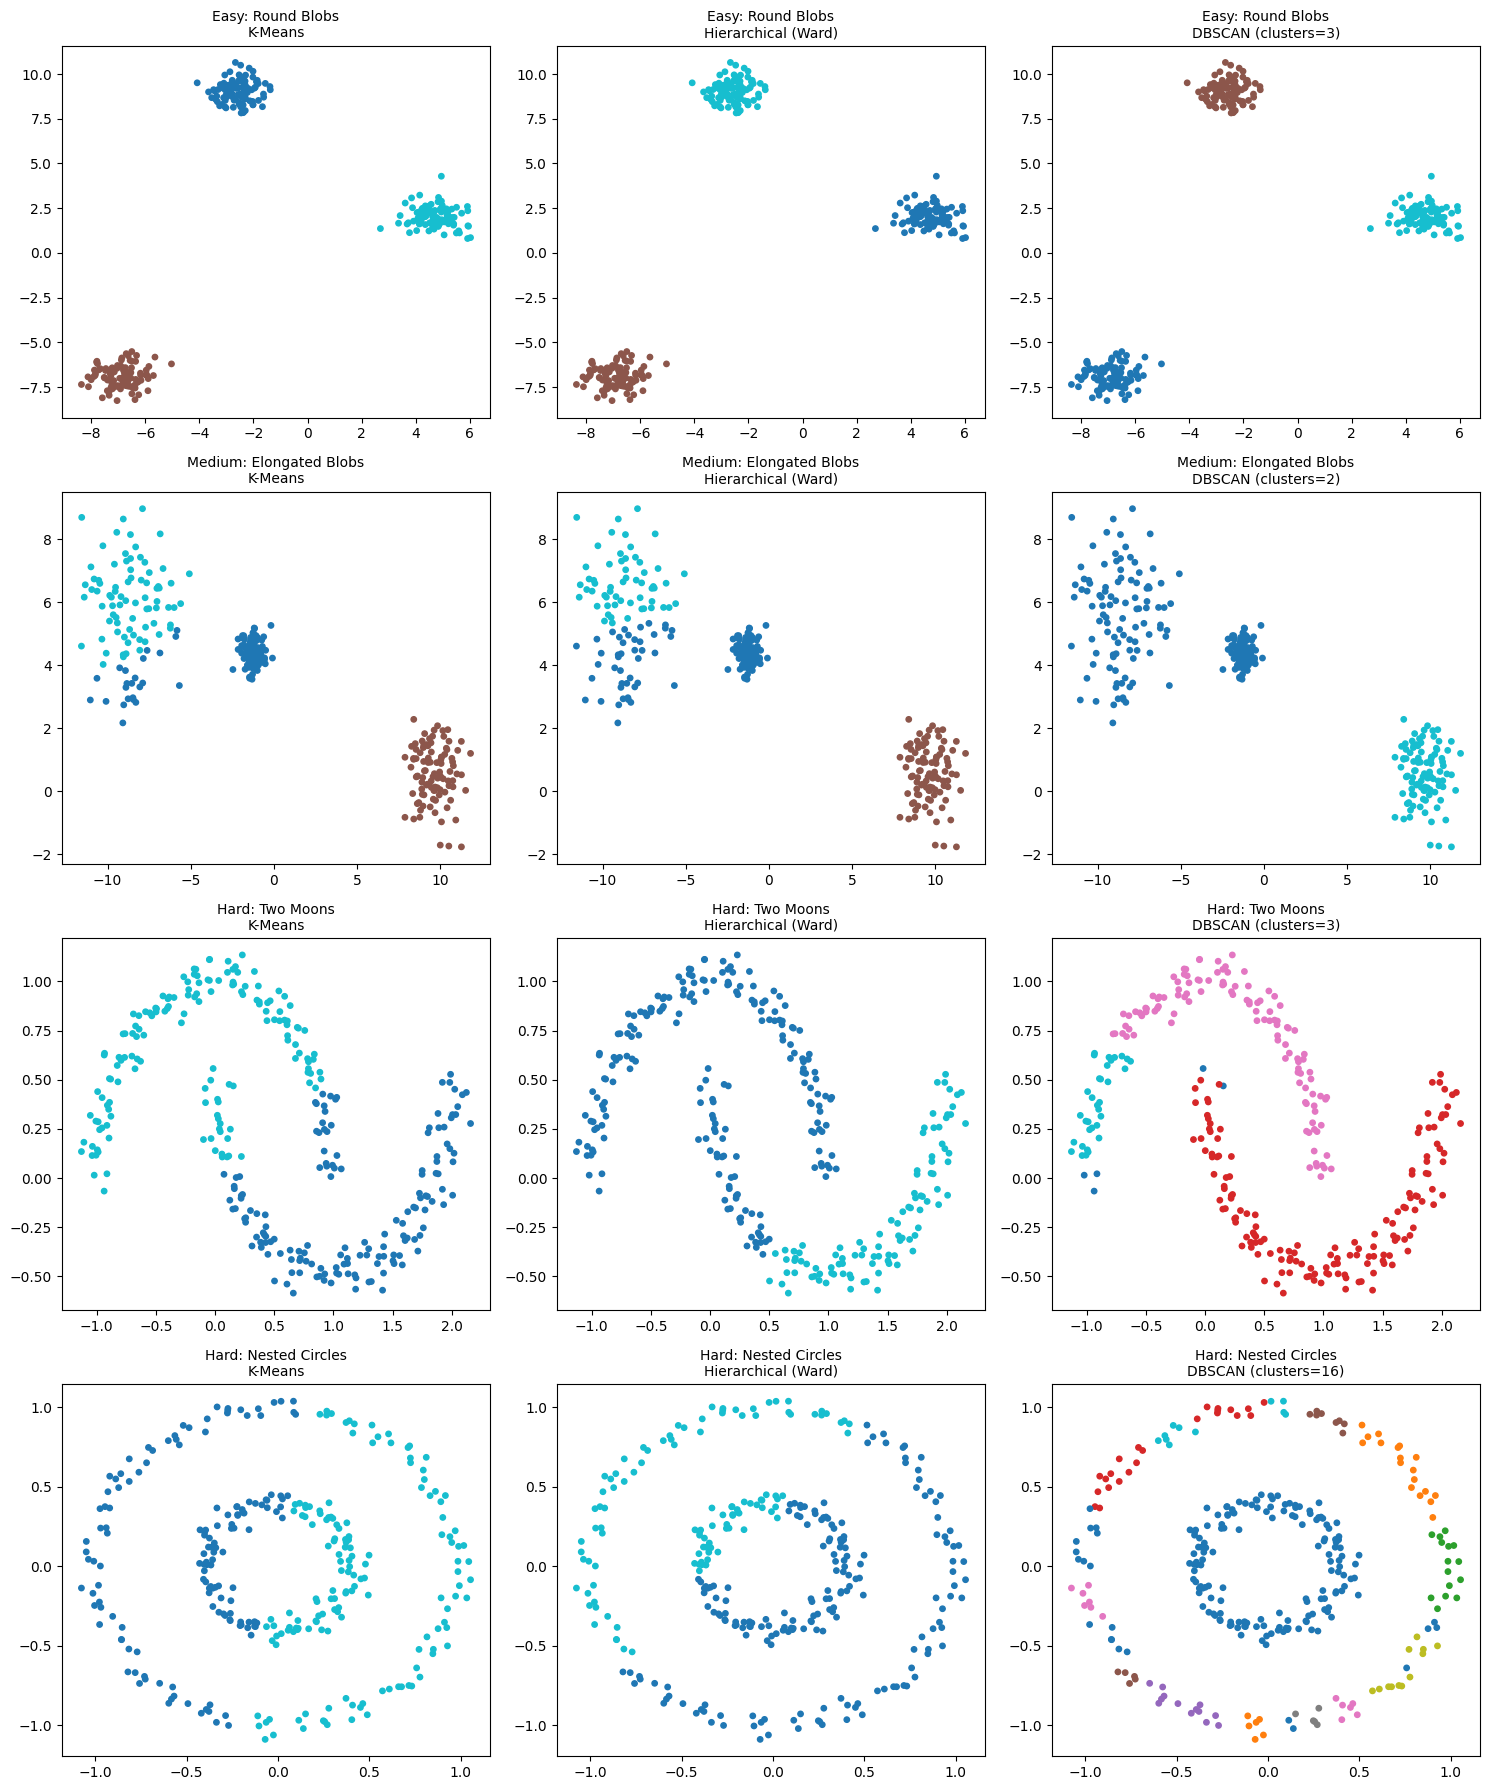

In [3]:
configs = {
    'Easy: Round Blobs': {'k': 3, 'eps': 0.5},
    'Medium: Elongated Blobs': {'k': 3, 'eps': 0.6},
    'Hard: Two Moons': {'k': 2, 'eps': 0.2},
    'Hard: Nested Circles': {'k': 2, 'eps': 0.2},
}

fig, axes = plt.subplots(4, 3, figsize=(15, 18))

for row, (name, X) in enumerate(datasets.items()):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    k = configs[name]['k']
    eps = configs[name]['eps']

    km_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    hier_labels = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward').fit_predict(X_scaled)
    db_labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)

    axes[row, 0].scatter(X[:, 0], X[:, 1], c=km_labels, cmap='tab10', s=15)
    axes[row, 0].set_title(f'{name}\nK-Means', fontsize=10)

    axes[row, 1].scatter(X[:, 0], X[:, 1], c=hier_labels, cmap='tab10', s=15)
    axes[row, 1].set_title(f'{name}\nHierarchical (Ward)', fontsize=10)

    axes[row, 2].scatter(X[:, 0], X[:, 1], c=db_labels, cmap='tab10', s=15)
    n_found = len(set(db_labels)) - (1 if -1 in db_labels else 0)
    axes[row, 2].set_title(f'{name}\nDBSCAN (clusters={n_found})', fontsize=10)

plt.tight_layout()
plt.show()


## 4. Quantify the Difference with Silhouette Score

Silhouette score isn't a perfect metric for comparing across algorithms (DBSCAN's noise points
complicate the calculation), but it gives us a useful numeric sanity check for the "easy" cases.

In [4]:
results = []
for name, X in datasets.items():
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    k = configs[name]['k']
    eps = configs[name]['eps']

    km_labels = KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled)
    hier_labels = AgglomerativeClustering(n_clusters=k, metric='euclidean', linkage='ward').fit_predict(X_scaled)
    db_labels = DBSCAN(eps=eps, min_samples=5).fit_predict(X_scaled)

    row = {'dataset': name}
    row['kmeans_silhouette'] = round(silhouette_score(X_scaled, km_labels), 3)
    row['hierarchical_silhouette'] = round(silhouette_score(X_scaled, hier_labels), 3)
    # only compute DBSCAN silhouette if it found more than 1 cluster (excluding all-noise edge case)
    if len(set(db_labels)) > 1:
        row['dbscan_silhouette'] = round(silhouette_score(X_scaled, db_labels), 3)
    else:
        row['dbscan_silhouette'] = float('nan')
    results.append(row)

import pandas as pd
pd.DataFrame(results)


,dataset,kmeans_silhouette,hierarchical_silhouette,dbscan_silhouette
0,Easy: Round Blobs,0.909,0.909,0.909
1,Medium: Elongated Blobs,0.642,0.631,0.728
2,Hard: Two Moons,0.495,0.425,0.290
3,Hard: Nested Circles,0.325,0.307,0.235


## 5. Key Observations

- **On round, well-separated blobs**: all three algorithms perform similarly well -- there's no
  strong reason to prefer DBSCAN here, and K-Means is simplest/fastest.
- **On elongated/unevenly-shaped blobs**: K-Means starts to struggle because it assumes roughly
  spherical clusters; Hierarchical and DBSCAN handle this better.
- **On two moons / nested circles (non-linear shapes)**: K-Means and Hierarchical Clustering both
  fail to separate the true underlying groups correctly, while **DBSCAN succeeds** by following
  the actual density-connected shape of each group.

**The practical lesson:** always visually inspect your data's shape (via a scatter plot or PCA
projection) before picking a clustering algorithm. If you see round, evenly-sized blobs, K-Means
is a perfectly good (and fast) choice. If shapes look irregular, elongated, nested, or you expect
noisy outliers, reach for DBSCAN.

## 6. Try It Yourself

- Add a 5th dataset shape of your own (e.g., `make_swiss_roll` projected to 2D, or a spiral).
- Try deliberately picking a bad `epsilon` for DBSCAN on the moons dataset and watch it fail too --
  this proves DBSCAN isn't magic, it just needs the right hyperparameter for the data's density.
- Time each algorithm (`%timeit`) on a much larger synthetic dataset (e.g., 20,000 points) to see
  the real-world scalability differences discussed in the notes.
